### Paso 1: Configuración del Entorno

*(Pipeline – load)*

En esta primera fase del pipeline realizaremos lo siguiente:
- Importación de librerías.
- Carga del dataset utilizando el módulo modular src/io.py.
- Visualización de la información del dataset.
- Inspección visual rápida de la estructura de los datos antes del proceso de limpieza.

In [1]:
from pathlib import Path
import sys

root_path = Path("..").resolve() 
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.io import *

# Cargar el dataset
df = load_csv()
print("Memory Usage: ", df.memory_usage(deep=True).sum())

# Visualizar informacion
print("Lista de Columnas:\n",df.columns)
print(f"Número de filas: {df.shape[0]} -- Número de columnas: {df.shape[1]}")

display("Valores Null",df.isnull().sum())
display("Filas duplicadas",df.duplicated().sum())

print("Análisis Variables numéricas")
var_numericas = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count']
display(df[var_numericas].describe())

print("Análisis Variables categéricas")
var_categoricas = ['title', 'genres', 'production_companies','original_language']
for var in var_categoricas:
    display(df[var].value_counts())


Memory Usage:  1761302037
Lista de Columnas:
 Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'budget', 'imdb_id', 'original_language',
       'original_title', 'overview', 'popularity', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'cast', 'director', 'director_of_photography', 'writers', 'producers',
       'music_composer', 'imdb_rating', 'imdb_votes', 'poster_path'],
      dtype='str')
Número de filas: 1196662 -- Número de columnas: 28


'Valores Null'

id                               0
title                            9
vote_average                     0
vote_count                       0
status                           0
release_date                126475
revenue                          0
runtime                          0
budget                           0
imdb_id                     528889
original_language                0
original_title                   8
overview                    183299
popularity                       0
tagline                    1014681
genres                      322423
production_companies        619900
production_countries        444213
spoken_languages            436179
cast                        379921
director                    193108
director_of_photography     873913
writers                     590942
producers                   787163
music_composer             1060675
imdb_rating                 727357
imdb_votes                  727357
poster_path                 292145
dtype: int64

'Filas duplicadas'

np.int64(0)

...

Análisis Variables categéricas


title
Home                                                                        190
Untitled                                                                    166
Mother                                                                      126
Alone                                                                       120
Echo                                                                        101
                                                                           ... 
On tape                                                                       1
Venise : l'âge d'or                                                           1
Inside The Works: Pioneering Computer Animation in a Long Island Mansion      1
Rare Birds in these Lands                                                     1
КОМАНДА ХАБИБА ПРОТИВ КОМАНДЫ ЛЮДЕЙ ИКС                                       1
Name: count, Length: 1008140, dtype: int64

genres
Documentary                                                    182937
Drama                                                          134839
Comedy                                                          70074
Animation                                                       38599
Music                                                           32402
                                                                ...  
Drama, Comedy, Thriller, Adventure                                  1
Drama, Adventure, Comedy, Romance, Fantasy, Science Fiction         1
Adventure, Comedy, Drama, Fantasy, Music                            1
Thriller, Mystery, Drama, Action                                    1
Crime, History, Horror, Thriller                                    1
Name: count, Length: 16122, dtype: int64

production_companies
BBC                                      2724
ONF | NFB                                2695
Metro-Goldwyn-Mayer                      2051
Columbia Pictures                        2007
Toei Company                             1884
                                         ... 
McGeehan Films, SOCAPA                      1
Tripsitter                                  1
Chimps Productions, What's in The Box       1
Human Error Club                            1
Creart Creative                             1
Name: count, Length: 270222, dtype: int64

original_language
en    582353
fr     77303
es     72896
de     54369
ja     54181
       ...  
kg         1
aa         1
kj         1
io         1
nr         1
Name: count, Length: 176, dtype: int64

# Paso 2. Limpieza de los datos
*(Pipeline – clean)*
1. Eliminación de columnas que no son necesarias para el análisis.
   [``imdb_id``, ``overview``, ``tagline``, ``poster_path``,  ``cast``,
    ``director_of_photography``, ``writers``, ``producers``, ``music_composer``,
    ``spoken_languages``, ``production_countries``, ``original_language``,
    ``imdb_rating``, ``imdb_votes``]
2. Transformar variables  numéricas a formato int [``budget``, ``revenue``, ``vote_count``, ``runtime``, ``popularity``, ``vote_average``]
3. Filtrar la columna (``runtime``)  > 60 para obtener solo las peliculas.
4. Filtrar las columnas (``budget, revenue``) con valor > 0 para calcular metricas.
  

In [2]:
from src.cleaning import *
# 1- Eliminar columnas irrelevantes
df_clean = drop_columns(df)

# 2- Convertir variables numéricas a tipos int
df_to_int = convertir_a_enteros(df_clean)

# 3- Filtrar solo las peliculas con runtime > 60 
df_only_movies = filter_only_movies(df_to_int)

# 4- Filtrar las columnas (``budget, revenue``) con valor > 0 para calcular el ROI.
df_numerics = filter_numeric_columns(df_only_movies)

print("RESUMEN")
display(f"Total Columns Antes de Eliminar: {df.shape[1]}", 
        f"Total Columns Después de Eliminar: {df_clean.shape[1]}")
print("Total de peliculas: ",df_only_movies.shape[0])
display(df_numerics.loc[:10, ['title','runtime', 'budget','revenue']])

RESUMEN


'Total Columns Antes de Eliminar: 28'

'Total Columns Después de Eliminar: 12'

Total de peliculas:  389021


,title,runtime,budget,revenue
2,Four Rooms,98,4000000,4257354
3,Judgment Night,109,21000000,12136938
6,Star Wars,121,11000000,775398007
7,Finding Nemo,100,94000000,940335536
8,Forrest Gump,142,55000000,677387716
9,American Beauty,122,15000000,356296601
10,Citizen Kane,119,839727,23218000


# Paso 3. Crear Features
*(Pipeline – features)*

1. Adicionar nueva columna con el año de la publicacion.
2. Adicionar nueva columna con el calculo del **ROI(Retorno de Inversión)**
   formula = $$ROI = \frac{Revenue - Budget}{Budget}$$

| ROI       | Tipo             | Interpretación                                                      |
| --------- | ---------------- | ------------------------------------------------------------------- |
| 0.064339  | Positivo pequeño | La película ganó un 6.4% más de lo invertido                        |
| -0.422051 | Negativo         | La película perdió aproximadamente un 42.2% del presupuesto         |
| 11.316140 | Muy alto         | La película ganó un 1131% del presupuesto (≈ 11 veces lo invertido) |

3. Adicionar nueva columna categorica basada en el **ROI**
   
| Categoría          | Rango de ROI | Interpretación                     |
| ------------------ | ------------ | ---------------------------------- |
| ***loss***         | ROI < 0      | La película pierde dinero          |
| ***low_revenue***  | 0 ≤ ROI < 1  | Recaudación baja o moderada        |
| ***high_revenue*** | ROI ≥ 1      | Recaudación alta / éxito comercial |

4. Transforma la columna ``genres`` en formato lista.


In [3]:
from src.features import *
#1. Nueva Columna Year
df_feature = add_year_feature(df_numerics)

#2. Nueva Columna ROI
df_feature = add_roi_feature(df_feature)
df_feature = add_roi_percentage(df_feature)

#3. Adicionar nueva columna categorica basada en el **ROI**
df_feature = add_roi_category(df_feature)

#4. Transforma la columna ``genres`` en formato lista.
df_feature = transform_genres(df_feature)

display(df_feature.head())

,id,title,vote_average,vote_count,release_date,revenue,runtime,budget,popularity,genres,production_companies,director,year,roi,roi%,roi_category
2,5,Four Rooms,5,2828,1995-12-09,4257354,98,4000000,3,[Comedy],"Miramax, A Band Apart","Quentin Tarantino, Allison Anders, Robert Rodr...",1995,0.064339,6.43,Media
3,6,Judgment Night,6,370,1993-10-15,12136938,109,21000000,2,"[Action, Crime, Thriller]","Largo Entertainment, JVC, Universal Pictures",Stephen Hopkins,1993,-0.422051,-42.21,Pedida
6,11,Star Wars,8,22271,1977-05-25,775398007,121,11000000,25,"[Adventure, Action, Science Fiction]",Lucasfilm Ltd.,George Lucas,1977,69.490728,6949.07,Alta
7,12,Finding Nemo,7,20501,2003-05-30,940335536,100,94000000,20,"[Animation, Family, Adventure]",Pixar,Andrew Stanton,2003,9.003570,900.36,Alta
8,13,Forrest Gump,8,29688,1994-06-23,677387716,142,55000000,28,"[Comedy, Drama, Romance]","Paramount Pictures, The Steve Tisch Company, W...",Robert Zemeckis,1994,11.316140,1131.61,Alta


## Paso 4: Conclusiones y Vizualización
*(Pipeline – viz)* 

### Q1. ¿Mayor presupuesto genera ROI positivo?

Hallasgoz:
- La línea de regresión es casi horizontal y cercana a 0, indicando que aumentar el presupuesto NO genera un mayor retorno de la inversión.
- Los outliers están en presupuestos BAJOS.
- Las películas caras tienden a generar un retorno de la inversión muy bajo o negativo.

Conclusión:
- "Mayor presupuesto NO genera mayor retorno de la inversión": Las películas con mayor ROI son las de menor presupuesto, mientras que las películas costosas tienden a tener un retorno de la inversion entorno a 0(low_revenue	0 ≤ ROI < 1	Recaudación baja o moderada).

-0.99999999 3000002.5


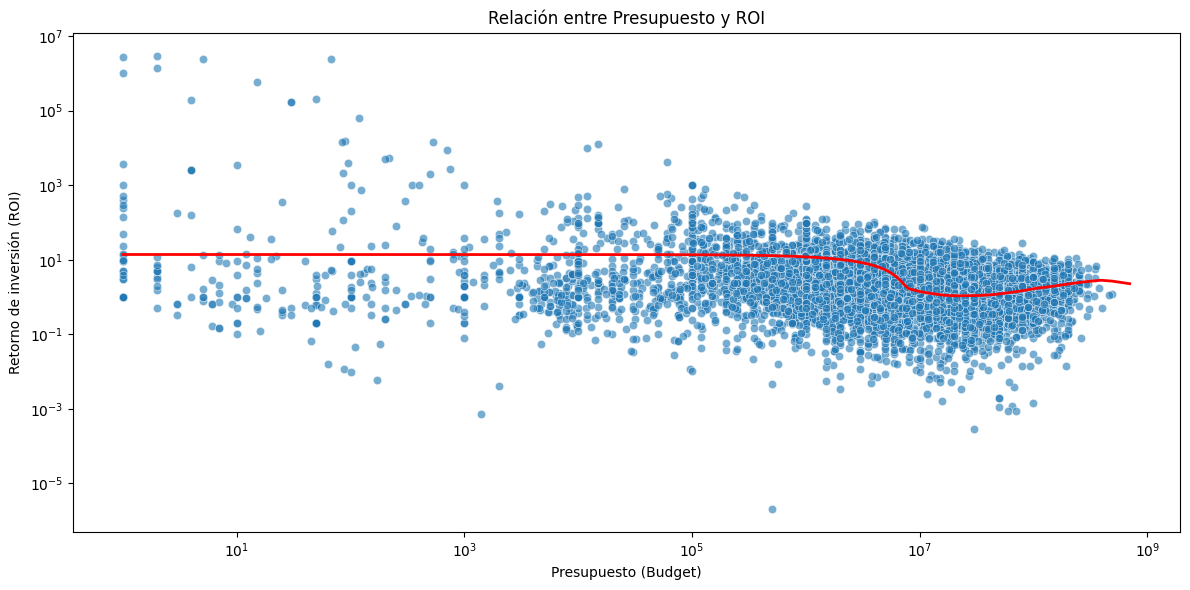

In [ ]:
from src.viz import *

#Q1. ¿Mayor inversión genera ROI positivo?
scatterplot_q1(df_feature)


### Q2 ¿Qué género de películas tiene mayor presupuesto?
Hallazgos:
- El género en el que mas dinero se invierte es en el de ***Aventuras*** con un total de ~$50M de presupuesto promedio.
- Le sigue ***Ciencia Ficción*** y ***Animación***

Conclusión:
- Las películas de aventura, ciencia ficción y animación son inversiones de alto riesgo pero alto potencial, mientras que dramas, documentales y películas de TV son producciones más modestas.

D:\Master Data Science\Master_Data_Science\Proyecto_Final\src\viz.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_budget.index[:20], y=genre_budget.values[:20], palette='viridis')


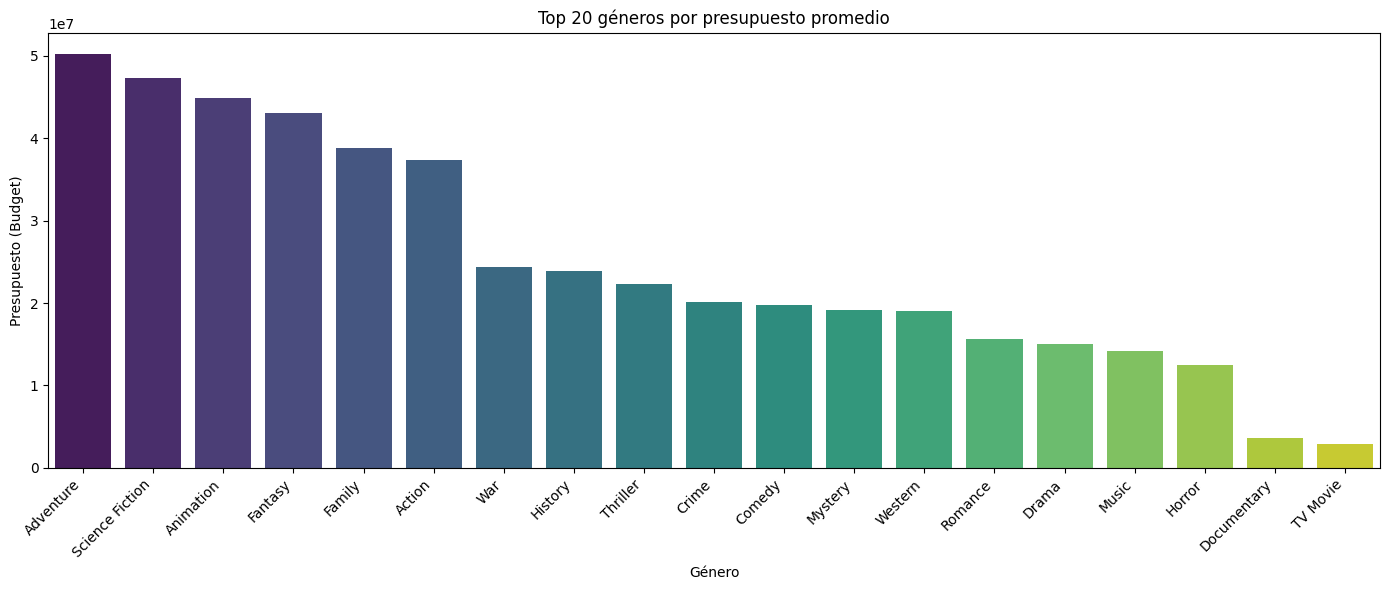

In [5]:
#Q2 ¿Qué género de películas tiene mayor presupuesto?
barplot_q2(df_feature)

### Q3. ¿Qué género de películas tiene mayor ROI?
Hallazgos:
- El genero de pelicula que tiene mayor retorno de inversion es el TV Movie con ~$27,000 de ROI promedio.
- Luego le sigue Documental y Musical
- Estos géneros "económicos" son los más rentables proporcionalmente

Conclusión:
- "Los géneros más rentables son los más baratos" — Existe una relación inversamente proporcional: a menor presupuesto invertido, mayor es el retorno porcentual. TV Movies, documentales y películas musicales con presupuestos bajos generan retornos extraordinarios, mientras que las grandes producciones (Adventure, Sci-Fi) tienen dificultades para justificar sus inversiones masivas en términos de ROI.

D:\Master Data Science\Master_Data_Science\Proyecto_Final\src\viz.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_roi.index[:20], y=genre_roi.values[:20], palette='viridis')


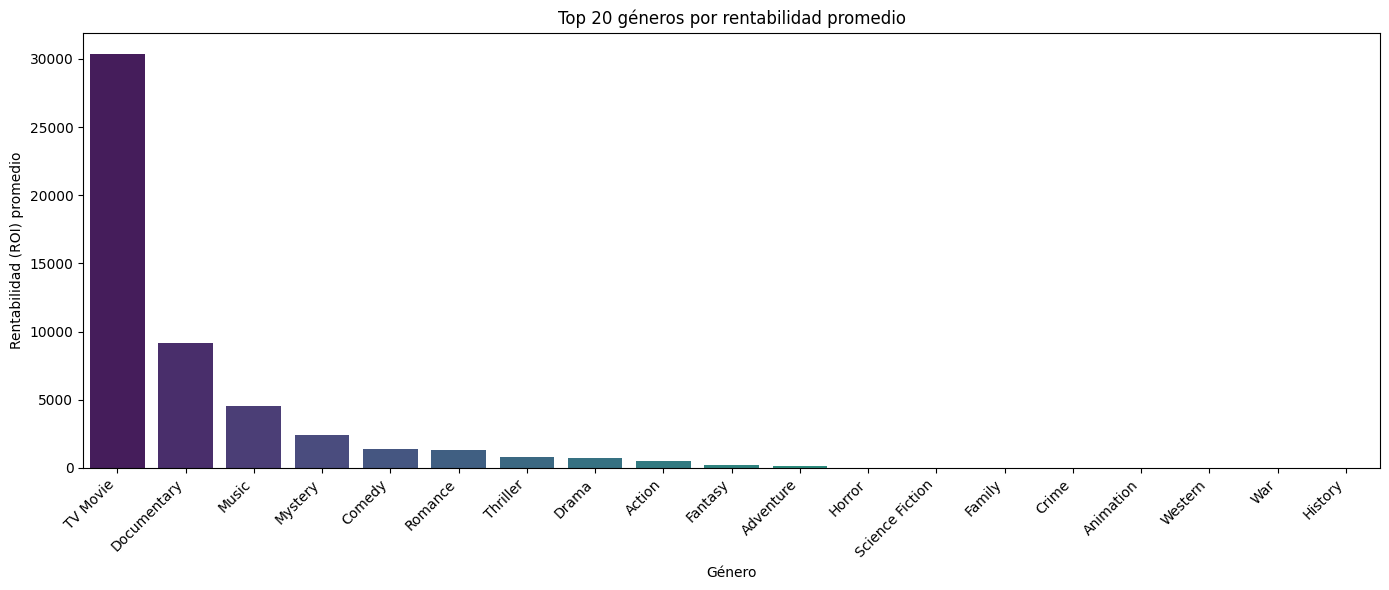

In [6]:
# Q3. ¿Qué género de películas tiene mayor ROI?
boxplot_q3(df_feature)

### Q4. ¿La película más popular es la que más ROI tiene?

Eje X: Popularidad (escala logarítmica) — qué tan viral/conocida es la película
Eje Y: Calificación crítica (vote_average) — qué tan bien la calificó la audiencia
Color: ROI — representado en escala roja (bajo/negativo) a verde (alto/positivo)

Hallazgos:
- NO hay relación clara entre popularidad y crítica.
- La mayoría de películas se concentran en:
    - Popularidad baja a moderada (izquierda-centro del gráfico)
    - Calificaciones entre 6-8 (zona media vertical)
    - Colores rojo oscuro/marrón (ROI bajo o negativo)
- Esto indica que la mayoría de películas son poco populares y poco rentables.

Conclusión:
- La zona ideal de máxima rentabilidad no existe en este dataset. Incluso una película que es popular Y bien calificada por la crítica tiende a tener ROI muy bajo, lo que sugiere que el costo de producción/marketing de esas películas es tan alto que sus ingresos no justifican la inversión.

Correlación entre popularidad y calificación crítica: 0.1510


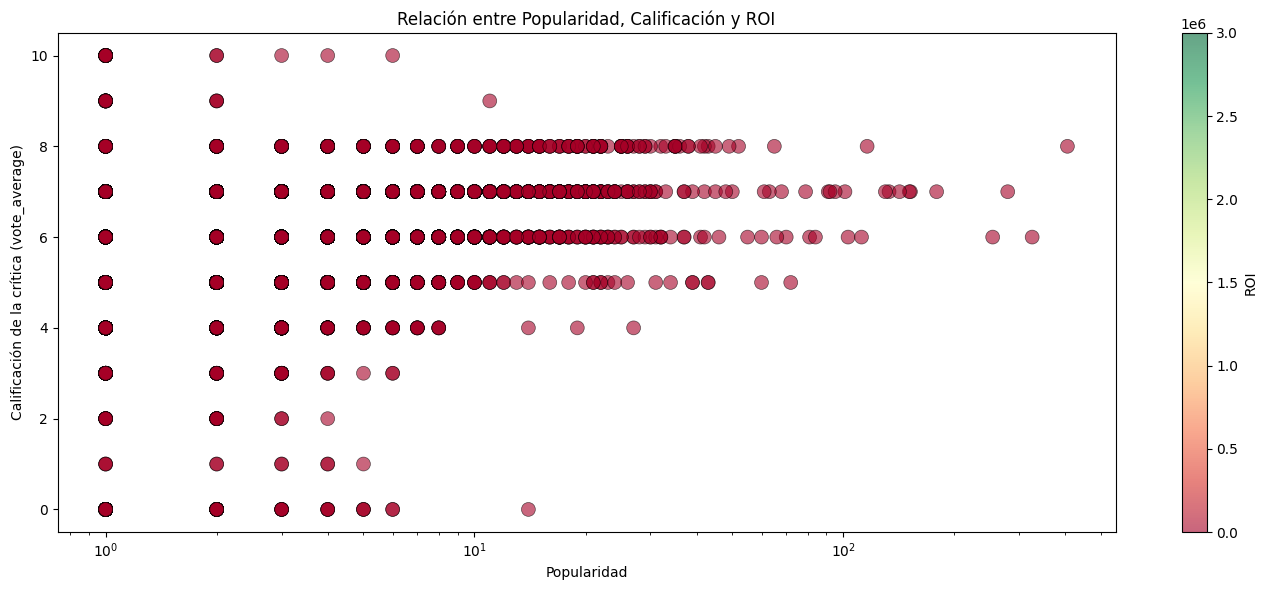

In [7]:
# Q4. ¿La película más popular es la que más ROI tiene?

# Calcular correlación
correlation = df_feature[['popularity', 'vote_average']].corr().iloc[0, 1]
print(f"Correlación entre popularidad y calificación crítica: {correlation:.4f}")

scatterplot_q4(df_feature)

### Q5. ¿Cuáles son las "joyas escondidas" (alta valoración, alto ROI)?
criterios: ROI >= 1 (>=100%), calificación >= 7
- El análisis de "joyas escondidas" (películas con ROI ≥ 100% y calificación ≥ 7) revela que la calificación crítica alta NO predice rentabilidad. 
- La mayoría de estos casos se concentran en calificaciones moderadamente altas (8.0-8.2), mientras que a calificaciones superiores (9.0+) son extremadamente raras.
-  Más importante aún, a una misma calificación crítica existe una varianza enorme en ROI: películas idénticamente valoradas pueden tener retornos que van desde apenas rentables (ROI ~1) hasta extraordinarios (ROI >1,000), demostrando que la crítica es un predictor débil de ganancias.
- Las "joyas escondidas" existen pero son excepcionales—incluso películas con calificación perfecta (10.0) mantienen ROI altamente variable. 
- Esto sugiere que la rentabilidad cinematográfica depende de factores mucho más complejos que la calidad crítica: presupuesto de producción, estrategia de marketing, fenómenos culturales virales y distribución, tienen más peso en la ecuación financiera que la valoración de expertos.

d:\Master Data Science\Master_Data_Science\Proyecto_Final\.mienv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


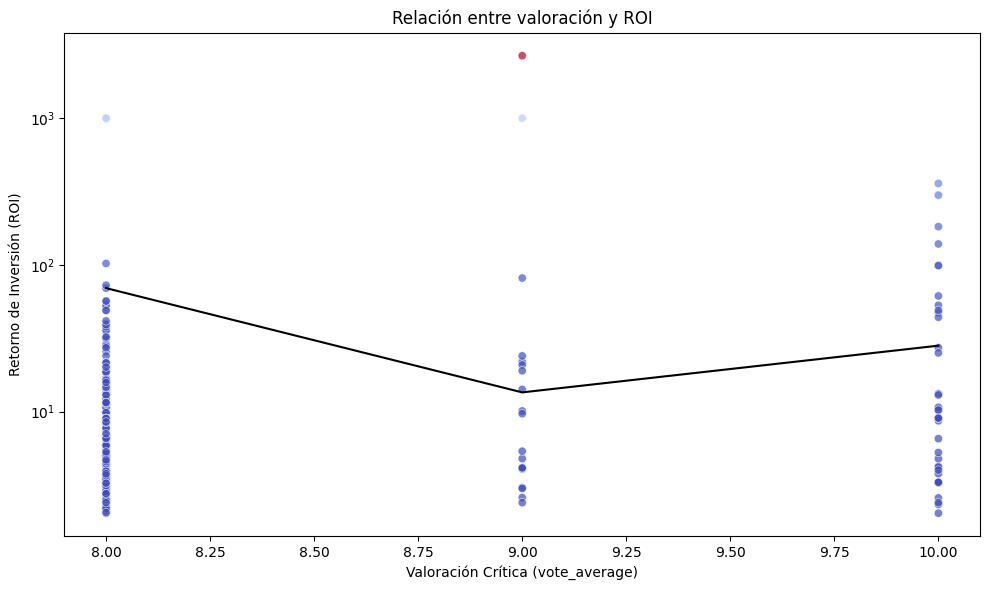

'Pelicula con mayor ROI'

id                                                                 270650
title                                              Oy Vey! My Son Is Gay!
vote_average                                                            4
vote_count                                                             30
release_date                                          2010-06-18 00:00:00
revenue                                                           6000007
runtime                                                                90
budget                                                                  2
popularity                                                              0
genres                                                  [Comedy, Romance]
production_companies    Oy Vey My Son Is Gay Productions, North by Nor...
director                                                Evgeny Afineevsky
year                                                                 2010
roi                                   

'Pelicula con mayor inversion'

id                                                                  19995
title                                                              Avatar
vote_average                                                            7
vote_count                                                          33914
release_date                                          2009-12-16 00:00:00
revenue                                                        2923706026
runtime                                                               162
budget                                                          237000000
popularity                                                             25
genres                               [Science Fiction, Action, Adventure]
production_companies    Dune Entertainment, Lightstorm Entertainment, ...
director                                                    James Cameron
year                                                                 2009
roi                                   

'Pelicula con mejor calificación'

id                                                   187527
title                   Tell 'em Steve-Dave: Puppet Theater
vote_average                                             10
vote_count                                                1
release_date                            2013-04-19 00:00:00
revenue                                                  46
runtime                                                  94
budget                                                   46
popularity                                                0
genres                                             [Comedy]
production_companies                                    NaN
director                                      Thorne Winter
year                                                   2013
roi                                                     0.0
roi%                                                    0.0
roi_category                                         Pedida
Name: 110084, dtype: object

In [8]:
# Q5. ¿Cuáles son las "joyas escondidas" (alta valoración, alto ROI)?

scatterplot_q5(df_feature)

display("Pelicula con mayor ROI", df_feature.loc[df_feature["roi"].idxmax()])
display("Pelicula con mayor inversion", df_feature.loc[df_feature["revenue"].idxmax()])
display("Pelicula con mejor calificación", df_feature.loc[df_feature["vote_average"].idxmax()])


# Paso 5. Exportar DataFrame a CSV
- Exportar el DataFrame a un fichero csv en data/processed

In [9]:
export_to_csv(df_feature)